<a href="https://colab.research.google.com/github/IngLuisGarcia17/NovaMarket_Retail_Customer_Behavior/blob/main/Project_NovaRetail_customer_behavior.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 7 - Exploring Behavioral Factors in NovaRetail+

NovaRetail+ is an e-commerce platform in Latin America with millions of users.

For the end of 2024, the **Growth and Retention** team aims to answer:

**What customer behavior factors are most strongly associated with annual revenue generated?**

> This project is a **correlational** (exploratory) analysis.
> **Correlation ≠ causation.**

## Section 1 - Load and explore the dataset

In this section, we validate:
- that the dataset loads correctly
- data types
- missing values / general ranges

Before correlating, we first understand the 'terrain'.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency

### Load Dataset

In [2]:
# Load the dataset and explore data
df = pd.read_csv('sample_data/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Dataset Description

The dataset contains the following columns:

- `id_cliente` — Unique customer identifier.
- `edad` — Customer's age.
- `nivel_ingreso` — Estimated annual income of the customer.
- `visitas_mes` — Number of visits to the application or website during the month.
- `compras_mes` — Number of purchases made in the month.
- `gasto_publicidad_dirigida` — Ad spend allocated to the user.
- `satisfaccion` — Customer satisfaction rating on a scale of 1 to 5.
- `miembro_premium` — Indicates if the customer has a premium subscription (1) or not (0).
- `abandono` — Indicates if the customer churned from the platform (1) or not (0).
- `tipo_dispositivo` — Type of device used by the customer (mobile, desktop, or tablet).
- `region` — Geographic region of the customer (north, south, west, or east).
- `ingreso_anual` — Annual revenue generated by the customer for the company.

The main analysis metric is `ingreso_anual`, used to evaluate the economic impact of customers.

In [3]:
# display the first 5 rows
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Section 2 - Prepare data and document assumptions

### Exploration and Cleaning

#### Initial Data Exploration
The dataset contains **15,000 records** and **12 columns**, with no null values.

**Numerical variables**
The following numerical columns are identified:
- `edad` (age)
- `nivel_ingreso` (anual income)
- `visitas_mes` (number of visits during the month)
- `compras_mes` (number of purchases made in the month)
- `gasto_publicidad_dirigida` (Ad spend allocated to the user)
- `satisfaccion` (Customer satisfaction rated)
- `ingreso_anual` (Anual_revenue)

Most of these variables have appropriate data types.
The column `edad` has float instead of int.

**Binary variables**
The following columns represent binary variables:
- `miembro_premium` (premium_member)
- `abandono` (churn)

Both are encoded as 0 and 1, **requiring no additional transformation**.

**Categorical variables**
The following categorical columns are identified:
- `id_cliente` (customer_id)
- `tipo_dispositivo` (device_type)
- `region` (region)

These variables are correctly defined and require no additional transformation.

In [4]:
# Correct the data type
df['edad'] = df['edad'].astype(int)

In [5]:
# verify changes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explore numerical variables

In [6]:
# Descriptive statistics of numerical variables
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


Initial diagnosis of numerical variables

- `edad` (age) the average age is 38, with a very balanced distribution.
- `nivel_ingreso` (anual income) some outliers due to high incomes, 75% under 36K max value 74K.
- `visitas_mes` (number of visits during the month) most users visit monthly about 10 times.
- `compras_mes` (number of purchases made in the month) 25% of customers have not made a purchase.
- `gasto_publicidad_dirigida` (Ad spend allocated to the user) seems a few users are receiving much more ad spend than others.
- `satisfaccion` (Customer satisfaction rated) 25% of users who are neutral or Dissatisfied with 3.1 on rates.
- `ingreso_anual` (Anual_revenue) 25% of customers have not made revenue.

#### Explore binary variables

In [7]:
# Verify that each column has only two possible values
df[['miembro_premium','abandono']].describe()

,miembro_premium,abandono
count,15000.000000,15000.000000
mean,0.139267,0.150733
std,0.346236,0.357801
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,1.000000,1.000000



Initial diagnosis of binary variables

- `miembro_premium` (premium_member) — 14% of customers are premium.
- `abandono` (churn) — 15% of customers are churn.

#### Explore categorical variables

In [8]:
# Verify the number of unique values per categorical variable
df[['tipo_dispositivo', 'region']].nunique()

,0
tipo_dispositivo,3
region,4


In [9]:
# Explore categorical variables and how they are distributed
categoric_cols = ['tipo_dispositivo', 'region']
for col in categoric_cols:
    print(df[col].value_counts(dropna = False, normalize= True))

tipo_dispositivo
móvil         0.654533
escritorio    0.248000
tablet        0.097467
Name: proportion, dtype: float64
region
norte    0.2930
oeste    0.2540
sur      0.2484
este     0.2046
Name: proportion, dtype: float64


Initial diagnosis of categorical variables

- `tipo_dispositivo` (device_type) — Majority of customers (65%) rather use the movil.
- `region` (region) - Distribution is uniform leading by North with 29%.

### Assumptions

- The analysis is performed using **the entire available dataset**.
- The data has no errors and is correctly typed.
- Different coefficients are used depending on the variable type:
  - **Pearson** assumes linear relationships between numerical variables.
  - **Spearman** evaluates monotonic relationships and does not require normality.
  - **Point-biserial** is used for numerical-binary relationships.
  - **Cramér's V** is used for associations between categorical variables.

**Central assumption:**
This analysis identifies relationships between variables or segments but does not prove causality.

## Section 3 - Visualization of relationships

We observe how numerical variables are related.

### Heatmap

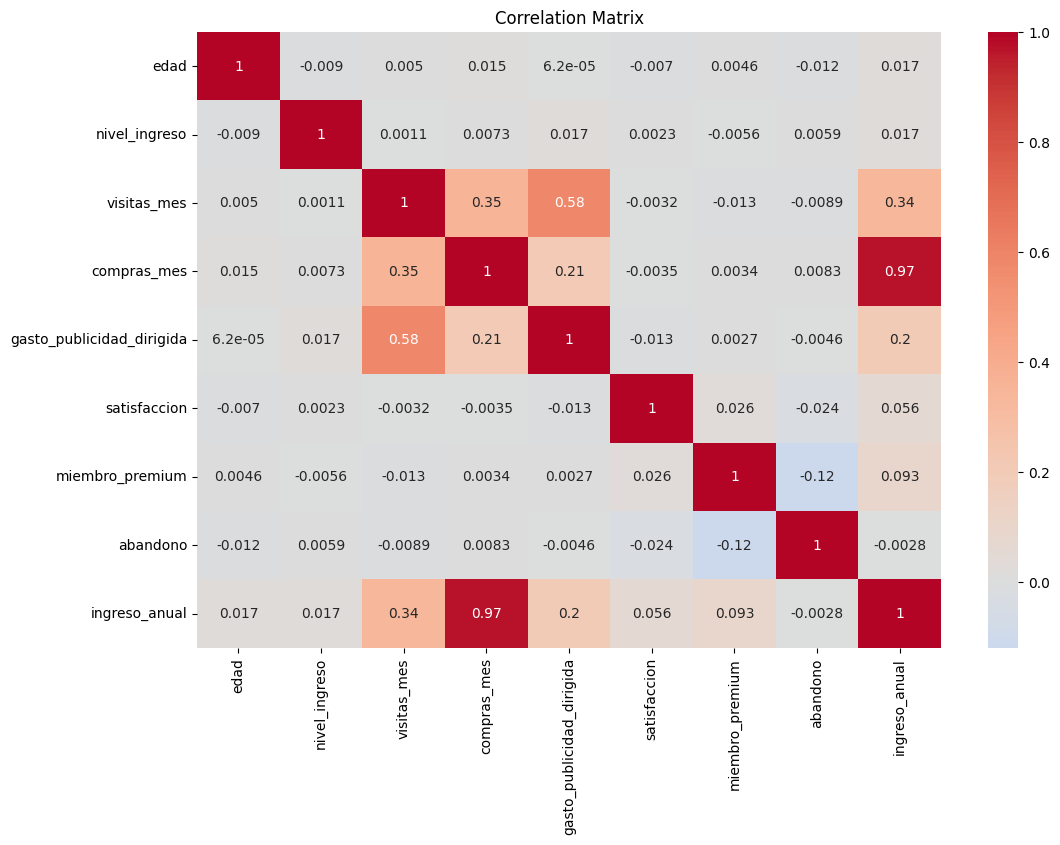

In [10]:
# Visualize the correlation matrix to identify relationships
df_corr = df.select_dtypes(include= ['number']).corr()
plt.figure(figsize=(12,8))
sns.heatmap(df_corr,
            annot = True,
            cmap= 'coolwarm',
            center = 0)
plt.title('Correlation Matrix')
plt.show()


General Observations (Heatmap)

- `visitas_mes` ↔ `gasto_publicidad_dirigida` (0.58): Moderate-high. Users with more monthly visits are associated with higher directed advertising spend toward them. This could reflect a targeting/segmentation pattern.
- `visitas_mes` ↔ `compras_mes` (0.35): Moderate correlations. More visits are associated with more purchases and higher income, but the relationship is not tight.
- `compras_mes` ↔ `gasto_publicidad_dirigida` (0.21): Weak-to-moderate, but present.
- `miembro_premium` ↔ `abandono` (-0.12): The only negative correlation with some relevance. Premium members tend to churn slightly less — though the value is low and should be interpreted with caution.


Observations regarding `ingreso_anual` (annual_revenue)
- `compras_mes` ↔ `ingreso_anual` (0.97): The strongest correlation in the entire matrix. Customers who buy more times per month tend to have higher annual income — or vice versa. This is an almost perfectly linear relationship.
- `visitas_mes` ↔ `ingreso_anual` (0.34): Moderate correlations. More visits are associated with more purchases and higher income, but the relationship is not tight.

### General Scatterplot

Based on the results of the correlation analysis, it is not necessary to generate a general scatterplot.

  - The general scatterplot matrix was omitted because most variables exhibit statistical independence (correlations $< 0.1$), which would result in visualizations lacking informative value.

### Scatterplot for key pairs

In [11]:
# Visualize pairs of variables with moderate or strong relationships
key_pairs = [('compras_mes', 'ingreso_anual'),
             ('visitas_mes', 'gasto_publicidad_dirigida'),
             ('visitas_mes', 'compras_mes'),
             ('visitas_mes', 'ingreso_anual'),
             ('compras_mes', 'gasto_publicidad_dirigida')]
# def to apply each key pairs

def scatterplot_key_pairs(df, key_pairs):
  for var_x, var_y in key_pairs:
    fig, ax = plt.subplots(figsize=(8, 5))

    sns.scatterplot(
        data=df,
        x=var_x,
        y=var_y,
        alpha = 0.3,
        edgecolor=None,
        color='steelblue',
        ax=ax
      )
    sns.regplot(
        data=df,
        x=var_x,
        y=var_y,
        scatter=False,
        color='crimson',
        ax=ax
      )

    ax.set_title(f'{var_x} vs {var_y}')
    ax.set_xlabel(var_x)
    ax.set_ylabel(var_y)
    plt.show()


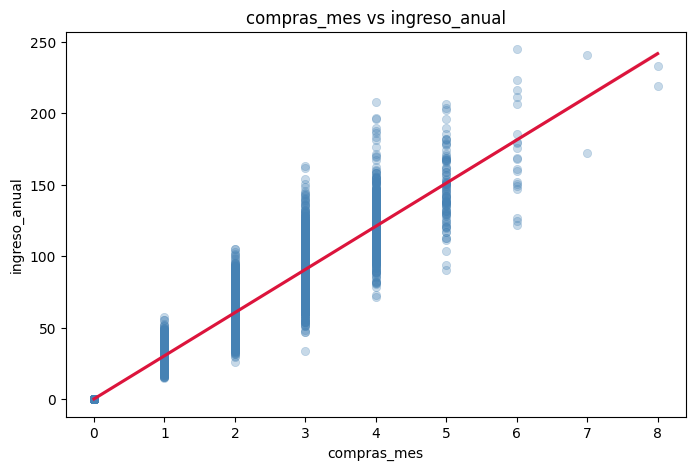

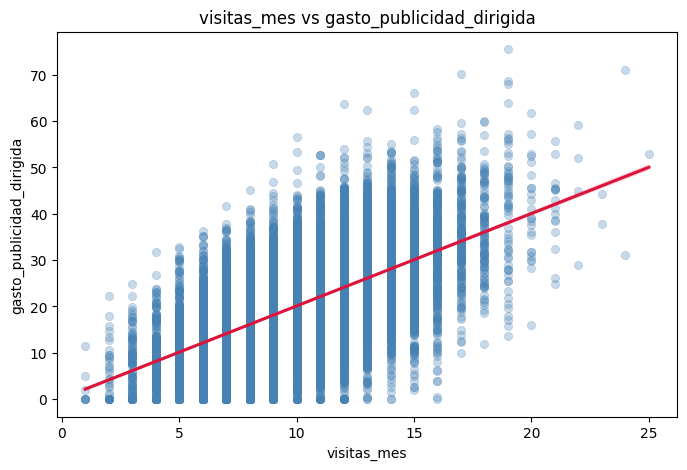

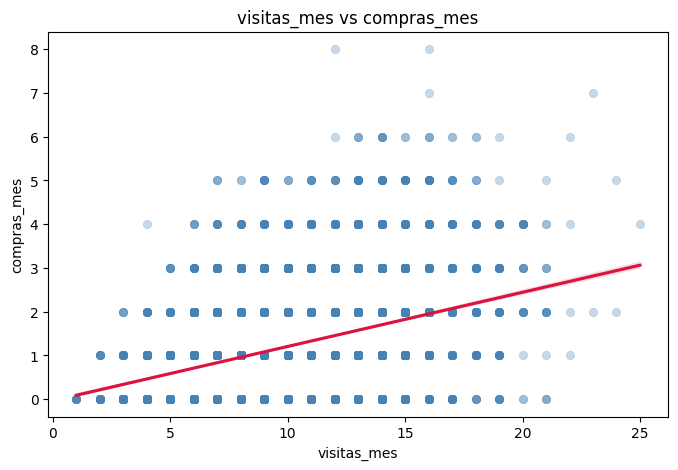

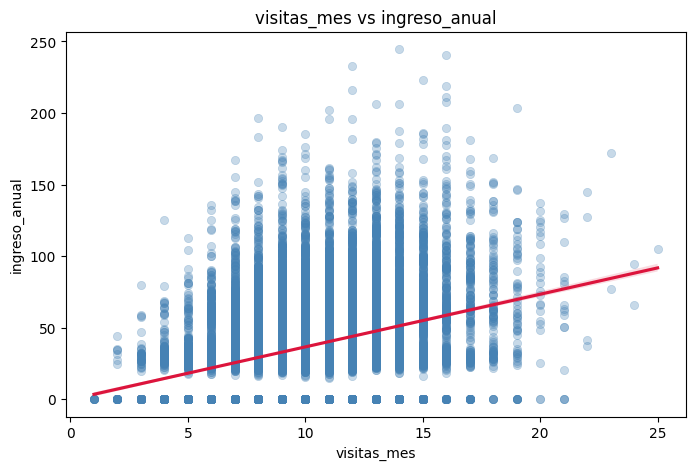

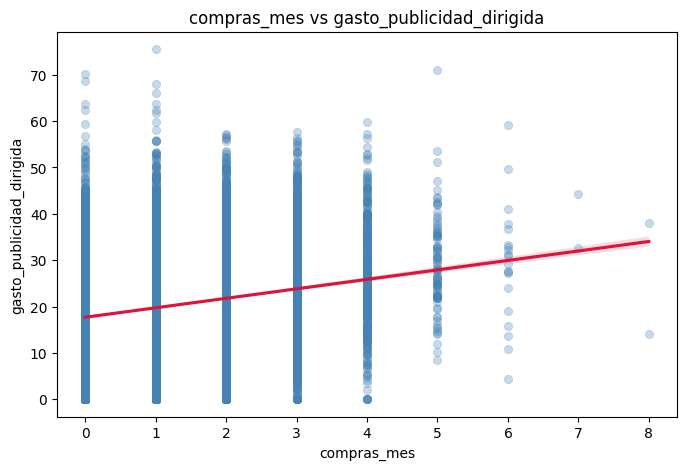

In [12]:
scatterplot_key_pairs(df, key_pairs)


Initial Observations (Scatterplot)
- Plot 1 — `compras_mes` vs `ingreso_anual` (r = 0.97)

    - Direction: Strong positive
    - Dispersion: Low
    - Outliers: Minimal, a few points at higher values deviate slightly
    - Collinearity: ⚠️ Very high risk. This near-perfect linear relationship strongly suggests these two variables carry almost identical information. One should likely be dropped or the relationship investigated at the data construction level.


- Plot 2 — `visitas_mes` vs `gasto_publicidad_dirigida` (r = 0.58)

    - Direction: Moderate positive
    - Dispersion: Medium-high - visitas_mes increases (possible heteroscedasticity)
    - Outliers: A few points above the cloud at high visit counts (~20–25)
    - Collinearity: Moderate concern if both are used together in a model, but not critical


- Plot 3 — `visitas_mes` vs `compras_mes` (r = 0.35)

    - Direction: Weak positive
    - Dispersion: High — the grid-like pattern confirms both variables are discrete integers
    - Outliers: A few isolated points at the top (compras = 7–8) stand out
    - Collinearity: Low risk


- Plot 4 — `visitas_mes` vs `ingreso_anual` (r = 0.34)

    - Direction: Weak positive
    - Dispersion: Very high — the vertical stacking is extreme, especially for lower visit counts. A dense cluster sits near ingreso_anual = 0 across all `visitas_mes` values
    - Outliers: Several high-income points (>200) scattered across mid-range visits
    - Collinearity: Low risk


- Plot 5 — `compras_mes` vs `gasto_publicidad_dirigida` (r = 0.21)

    - Direction: Weak positive
    - Dispersion: Very high — the wide vertical spread at each integer value of `compras_mes` means `gasto_publicidad_dirigida` is nearly independent of purchases
    - Outliers: A few points near 0 at `compras_mes` = 4 are suspicious
    - Collinearity: Very low risk


## Section 4 - Correlation coefficients and numerical evidence

In this section, coefficients that support the visually observed patterns are reported, using the appropriate method depending on the type of variables.

### Pearson / Spearman

In [13]:
# Calculate correlation between relevant variables
key_pairs_method = [
    ('compras_mes', 'ingreso_anual', 'pearson'),
    ('visitas_mes', 'gasto_publicidad_dirigida', 'pearson'),
    ('visitas_mes', 'compras_mes', 'spearman'),
    ('visitas_mes', 'ingreso_anual', 'spearman'),
    ('compras_mes', 'gasto_publicidad_dirigida', 'spearman')
]

results = []

for var_x, var_y, method in key_pairs_method:
  x = df[var_x]
  y = df[var_y]

  if method == 'pearson':
    coef, pval = stats.pearsonr(x, y)
  else:
    coef, pval = stats.spearmanr(x, y)

  results.append({
      'pair': f'{var_x} vs {var_y}',
      'method': method,
      'coefficient': round(coef, 4),
      'p-value': round (pval, 4),
      'significant': pval < 0.05
  })



In [14]:
corr_results = pd.DataFrame(results)
corr_results

,pair,method,coefficient,p-value,significant
0,compras_mes vs ingreso_anual,pearson,0.9671,0.0,True
1,visitas_mes vs gasto_publicidad_dirigida,pearson,0.5789,0.0,True
2,visitas_mes vs compras_mes,spearman,0.3329,0.0,True
3,visitas_mes vs ingreso_anual,spearman,0.3210,0.0,True
4,compras_mes vs gasto_publicidad_dirigida,spearman,0.1925,0.0,True



Correlation Observations

- `compras_mes` vs `ingreso_anual` — Pearson r = 0.967
    - Direction: Strong positive.
    - Magnitude: Near-perfect linear relationship. Every additional purchase per month is almost perfectly associated with higher annual income.
    - Collinearity: 🔴 Critical. A Pearson r of 0.967 means these two variables share ~93% of their variance (r²). Including both in any regression or classification model would cause severe multicollinearity. One must be excluded, or they should be combined into a single composite feature.

- `visitas_mes` vs `gasto_publicidad_dirigida` — Pearson r = 0.579
    - Direction: Moderate positive.
    - Magnitude: Users who visit more frequently are associated with higher directed ad spend.
    - Collinearity: 🟡 Moderate. Worth monitoring if both enter the same model, but not critical on its own.

- `visitas_mes` vs `compras_mes` — Spearman ρ = 0.333
    - Direction: Weak positive.
    - Magnitude: Low. More monthly visits weakly associate with more purchases, but the relationship is noisy — many users visit frequently without converting.
    - Collinearity: 🟢 Low risk.

- `visitas_mes` vs `ingreso_anual` — Spearman ρ = 0.321
    - Direction: Weak positive.
    - Magnitude: Very similar to the previous pair, which makes sense given `compras_mes` and `ingreso_anual` are nearly identical variables. The relationship is present but explains little variance.
    - Collinearity: 🟢 Low risk.

- `compras_mes` vs `gasto_publicidad_dirigida` — Spearman ρ = 0.193
    - Direction: Weak positive.
    - Magnitude: The weakest relationship among all pairs. Ad spend and purchase frequency barely move together, suggesting advertising may not be directly tied to conversion in this dataset.
    - Collinearity: 🟢 Negligible risk.


### Point-biserial

In [15]:
# Calculate correlation between relevant variables
numeric_cols = ['edad', 'nivel_ingreso', 'compras_mes', 'gasto_publicidad_dirigida','satisfaccion','ingreso_anual']
binary_cols = ['miembro_premium', 'abandono']

results_pb = []

for binary in binary_cols:
  for numeric in numeric_cols:
    coef, pval = stats.pointbiserialr(df[binary], df[numeric])
    results_pb.append({
        'binary_var': binary,
        'numeric_var': numeric,
        'coefficient': round(coef, 4),
        'p-value': round (pval, 4),
        'significant': pval < 0.05
    })



In [16]:
point_bi_results = pd.DataFrame(results_pb)
point_bi_results

,binary_var,numeric_var,coefficient,p-value,significant
0,miembro_premium,edad,0.0046,0.5728,False
1,miembro_premium,nivel_ingreso,-0.0056,0.4930,False
2,miembro_premium,compras_mes,0.0034,0.6744,False
3,miembro_premium,gasto_publicidad_dirigida,0.0027,0.7390,False
4,miembro_premium,satisfaccion,0.0257,0.0016,True
5,miembro_premium,ingreso_anual,0.0931,0.0000,True
6,abandono,edad,-0.0115,0.1590,False
7,abandono,nivel_ingreso,0.0059,0.4722,False
8,abandono,compras_mes,0.0083,0.3099,False
9,abandono,gasto_publicidad_dirigida,-0.0046,0.5744,False



Observations Point-biserial
- miembro_premium (premium_member)
  - `satisfaccion` (r = 0.026, p = 0.0016):
    - Statistically significant but practically negligible. Premium members show a very slight tendency toward higher satisfaction — the effect is real but tiny.
  - `ingreso_anual` (r = 0.093, p < 0.0001):
     - The strongest finding for this binary variable. Higher annual income is weakly but significantly associated with being a premium member, which is intuitive — premium membership likely has a cost barrier.
  - All others (`edad`, `nivel_ingreso`, `compras_mes`, `gasto_publicidad_dirigida`): Non-significant (p > 0.05).

- Abandono (churn)
  - `satisfaccion` (r = −0.024, p = 0.0035): Statistically significant and in the expected direction — lower satisfaction is weakly associated with higher churn. The effect is small but consistent with theory.
  - All others: Non-significant. Notably, show virtually zero association with churn, which is somewhat surprising.

### Cramér's V

In [17]:
# Function to calculate Cramér's V

def cramers_v (df, col1, col2):

  table = pd.crosstab(df[col1], df[col2])

  chi2, pval, dof, expected = chi2_contingency(table)

  n = table.values.sum()
  v = np.sqrt (chi2 / (n * (min(table.shape)-1)))

  return round(v, 4), round(pval, 4)

In [18]:
# Apply Cramér's V on relevant variables
cramers_v(df, 'region','tipo_dispositivo')

(np.float64(0.0124), np.float64(0.5965))

Observations Cramér's V
- Magnitude: Negligible (V < 0.10). `Region` and device type share virtually no association.
- p-value = 0.597: Non-significant — we cannot reject the null hypothesis of independence. The observed distribution could easily occur by chance.
- Conclusion: The device a customer uses `tipo_dispositivo` is independent of their `region`. Device choice does not vary meaningfully across geographic areas in this dataset.

## Section 5 - Interpretation of results for the business

Each finding should include:
1) Visual evidence (if applicable)
2) Numerical evidence
3) Interpretation (non-causal)
4) We cannot affirm
5) Business implication

---

✍️ **Findings**: Complete the following blocks.
If you deem it necessary, you can add more findings.

Remember to delete this text block before including the project in your portfolio.

### Finding 1 — Monthly Purchases an Anual Income (r= 0967)

**Visual Evidence:** Scatterplot 1 shows a tight, nearly perfect linear cloud between `compras_mes` and `ingreso_anual`, with minimal dispersion and few outliers.

**Numerical Evidence:** Pearson r= 0.967 statistically significant. This is a near-perfect positive linear correlation.

**Interpretation:** Customers who make more monthly purchases are associate with higher annual revenue.

**We cannot affirm:** That increasing purchases causes higher annual revenue, this could be a definitional relationship, or both variables may affect the same underlying construct. High collinearity if both are used together.

**Business Implication:** Monthly purchase frequency is the single strongest indicator of annual revenue. Strategies that increase purchase frequency, are likely to have the highest revenue impact.

### Finding 2 — Monthly Visits and Directed Ad Spend (r= 0.58)

**Visual Evidence:** Scatterplot 2 shows a moderate upward trend between `visitas_mes` and `gasto_publicidad_dirigida`, with more dispersion than Finding 1.

**Numerical Evidence:** Pearson r = 0.58, statistically significant (p < 0.001). Moderate-to-high positive correlation.

**Interpretation:** Customers with more monthly visits are associated with higher directed advertising spend targeted at them — likely reflecting a platform segmentation pattern where more active users receive more ad investment.

**We cannot affirm:** That advertising spend drives visits or vice versa — the directionality is unknown.

**Business Implication:** If the platform is investing more ad budget on already-active users, there may be a diminishing returns effect. Consider testing ad spend reallocation toward lower-visit segments to stimulate engagement in dormant users.

###Finding 3 — Monthly Visits and Monthly Purchases (Spearman ρ ≈ 0.35)

**Visual Evidence:** Scatterplot 3 shows a mild positive trend with high dispersion — many users visit frequently but purchase infrequently.

**Numerical Evidence:** Spearman ρ ≈ 0.35, statistically significant (p < 0.001).

**Interpretation:** More visits are moderately associated with more purchases, but the relationship is far from deterministic — a large segment of frequent visitors does not convert to buyers.

**We cannot affirm:** That driving more visits will automatically increase purchases. There is a meaningful "visit-but-not-buy" population that visits suggest engagement does not guarantee conversion.

**Business Implication:** Conversion optimization (better UX, cart recovery, targeted promotions at checkout) could unlock revenue from the high-visit/low-purchase segment without needing to increase traffic.

###Finding 4 — Premium Membership and Annual Income (Point-biserial r = 0.093)

**Visual Evidence:** No dedicated scatterplot (binary variable), but the point-biserial analysis is the evidence.

**Numerical Evidence:** Point-biserial r = 0.093, p < 0.001. Statistically significant but practically small.

**Interpretation:** Premium members are slightly associated with higher annual income. The effect is real but weak — premium status alone is not a strong revenue differentiator.

**We cannot affirm:** That converting users to premium plans will substantially increase annual revenue. The relationship may reflect that higher-income customers self-select into premium, not that the plan itself drives revenue.

**Business Implication:** Premium membership should not be the primary revenue lever. Consider enriching the premium tier's value proposition to strengthen the association between membership and spending behavior.

### **Limitations**
- Correlation ≠ causation — no causal claims can be made from this analysis
- The near-perfect `compras_mes` ↔ `ingreso_anual` correlation warrants investigation into whether these are partially derived from the same source
- Data reflects a single snapshot (end of 2024); seasonal effects are not captured

### **Next steps**


- Test additional segmentation

    - High-visit / low-purchase users (conversion gap segment)
    - Premium vs. non-premium revenue contribution by region


- Step 2: Build a multivariate regression excluding collinear variables (`compras_mes` + `ingreso_anual` should not both enter the same model)
- Step 3: Run a controlled A/B experiment on ad spend reallocation toward low-engagement users